# 01. Exploratory Data Analysis & Baseline Model

**Цель:** Провести первичный анализ данных Credit Card Fraud Detection, обработать признаковое пространство, сгенерировать базовые фичи и обучить baseline-модель (`LogisticRegression`).

In [17]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    classification_report, 
    roc_auc_score, 
    average_precision_score, 
    roc_curve, 
    precision_recall_curve
)

# Настройка стиля графиков
sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 5)

## 1. Загрузка и первичный осмотр данных

In [18]:
df = pd.read_csv('../data/creditcard.csv')

print(f"Размерность датасета: {df.shape}")
print(f"Количество пропущенных значений: {df.isnull().sum().sum()}")
print("\nПервые 5 строк:")
df.head()

Размерность датасета: (284807, 31)
Количество пропущенных значений: 0

Первые 5 строк:


,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 2. Анализ дисбаланса целевого класса

Честные транзакции (0): 284315 (99.827%)
Фродовые транзакции (1):  492 (0.173%)


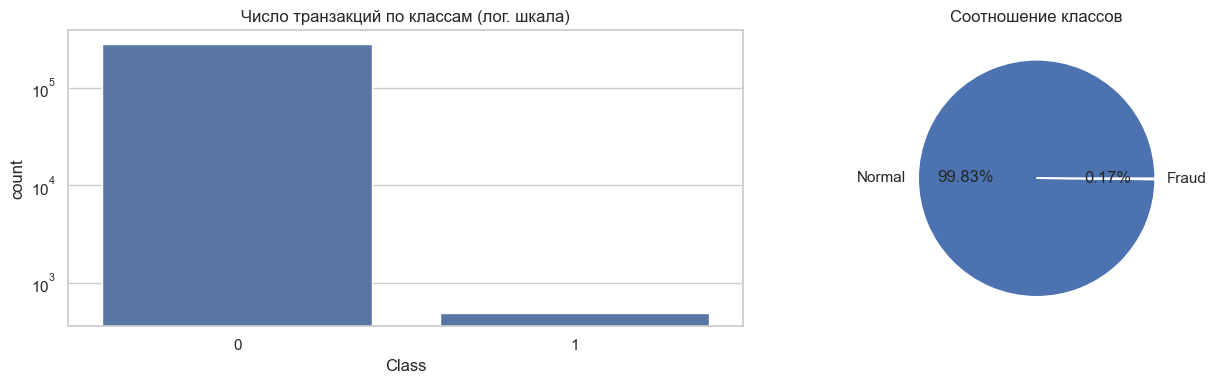

In [20]:
fraud_counts = df['Class'].value_counts()
fraud_percentages = df['Class'].value_counts(normalize=True) * 100

print(f"Честные транзакции (0): {fraud_counts[0]} ({fraud_percentages[0]:.3f}%)")
print(f"Фродовые транзакции (1):  {fraud_counts[1]} ({fraud_percentages[1]:.3f}%)")

fig, ax = plt.subplots(1, 2, figsize=(14, 4))

# Распределение транзакций
sns.countplot(data=df, x='Class', ax=ax[0])
ax[0].set_title('Число транзакций по классам (лог. шкала)')
ax[0].set_yscale('log')

# Доля фрода
ax[1].pie(fraud_counts, labels=['Normal', 'Fraud'], autopct='%1.2f%%', colors=['#4C72B0', '#C44E52'])
ax[1].set_title('Соотношение классов')

plt.tight_layout()
plt.show()

## 3. Feature Engineering (Генерация новых признаков)
* **Amount_log**: Логарифмирование суммы транзакции $\log(1 + \text{Amount})$ для устранения тяжёлого правого хвоста распределения.
* **Hour**: Извлечение часа суток $(0\dots23)$ из секундного счетчика `Time`.

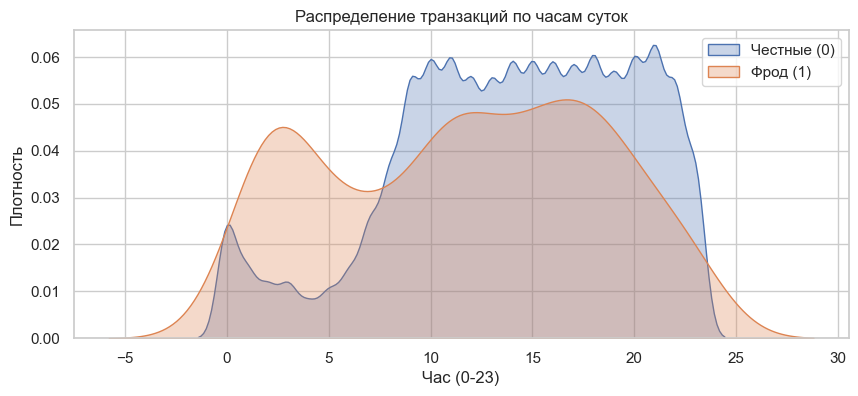

In [21]:
# Логарифмирование суммы
df['Amount_log'] = np.log1p(df['Amount'])

# Извлечение часа суток
df['Hour'] = (df['Time'] // 3600) % 24

# Распределение активности по часам
plt.figure(figsize=(10, 4))
sns.kdeplot(data=df[df['Class'] == 0]['Hour'], label='Честные (0)', common_norm=False, fill=True, alpha=0.3)
sns.kdeplot(data=df[df['Class'] == 1]['Hour'], label='Фрод (1)', common_norm=False, fill=True, alpha=0.3)
plt.title('Распределение транзакций по часам суток')
plt.xlabel('Час (0-23)')
plt.ylabel('Плотность')
plt.legend()
plt.show()

## 4. Обучение Baseline-модели (`LogisticRegression`)

In [22]:
# Выбор фичей (исключаем сырые Time, Amount и целевую переменную Class)
features = [col for col in df.columns if col not in ['Class', 'Time', 'Amount']]
X = df[features]
y = df['Class']

# Стратифицированное разделение (80% train / 20% test)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Размер обучающей выборки: {X_train.shape}")
print(f"Размер тестовой выборки:  {X_test.shape}")

# Обучение логистической регрессии
baseline_model = LogisticRegression(max_iter=1000, random_state=42)
baseline_model.fit(X_train, y_train)

# Предсказание вероятностей
y_pred_proba = baseline_model.predict_proba(X_test)[:, 1]

Размер обучающей выборки: (227845, 30)
Размер тестовой выборки:  (56962, 30)


/Users/artsiom/Documents/ML/pet_projects/fraud-detection-service/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: divide by zero encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/artsiom/Documents/ML/pet_projects/fraud-detection-service/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: overflow encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/artsiom/Documents/ML/pet_projects/fraud-detection-service/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:200: RuntimeWarning: invalid value encountered in matmul
  raw_prediction = X @ weights + intercept
/Users/artsiom/Documents/ML/pet_projects/fraud-detection-service/venv/lib/python3.9/site-packages/sklearn/linear_model/_linear_loss.py:330: RuntimeWarning: divide by zero encountered in matmul
  grad[:n_features] = X.T @ grad_pointwise + l2_reg_strength * weights
/Users/artsiom/Documents/ML/pet_pro

## 5. Оценка метрик (ROC-AUC & PR-AUC)

Baseline ROC-AUC Score: 0.9562
Baseline PR-AUC Score:  0.7395


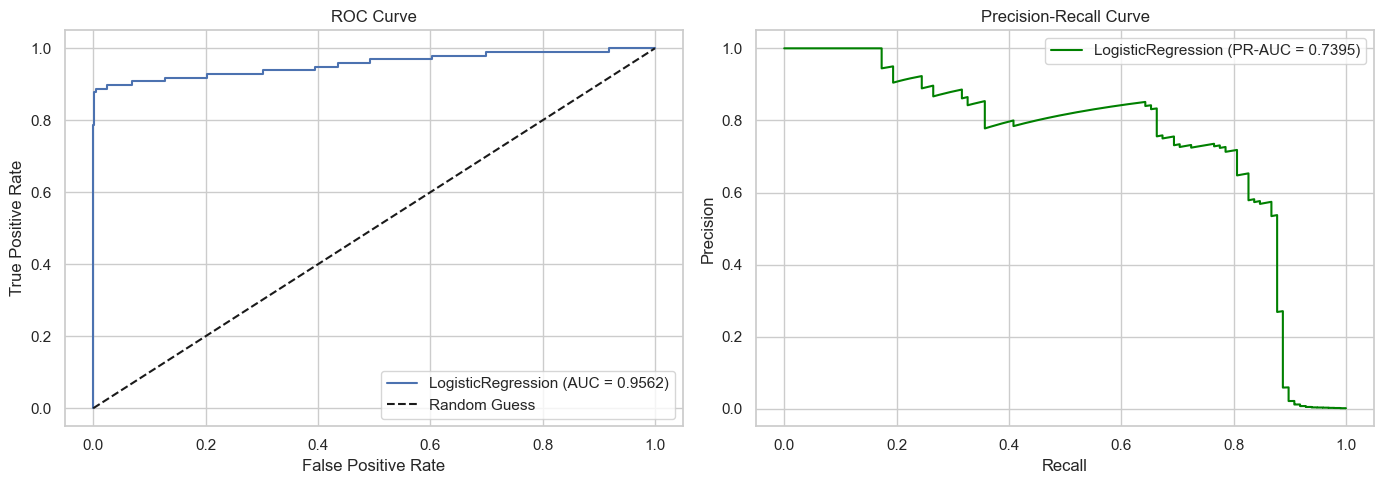

In [23]:
roc_auc = roc_auc_score(y_test, y_pred_proba)
pr_auc = average_precision_score(y_test, y_pred_proba)

print("=" * 45)
print(f"Baseline ROC-AUC Score: {roc_auc:.4f}")
print(f"Baseline PR-AUC Score:  {pr_auc:.4f}")
print("=" * 45)

# Построение графиков
fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# ROC-кривая
fpr, tpr, _ = roc_curve(y_test, y_pred_proba)
ax[0].plot(fpr, tpr, label=f'LogisticRegression (AUC = {roc_auc:.4f})')
ax[0].plot([0, 1], [0, 1], 'k--', label='Random Guess')
ax[0].set_title('ROC Curve')
ax[0].set_xlabel('False Positive Rate')
ax[0].set_ylabel('True Positive Rate')
ax[0].legend()

# Precision-Recall кривая
precision, recall, _ = precision_recall_curve(y_test, y_pred_proba)
ax[1].plot(recall, precision, label=f'LogisticRegression (PR-AUC = {pr_auc:.4f})', color='green')
ax[1].set_title('Precision-Recall Curve')
ax[1].set_xlabel('Recall')
ax[1].set_ylabel('Precision')
ax[1].legend()

plt.tight_layout()
plt.show()